In [1]:
import uproot 
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import seaborn as sns
import plotly.express as px


In [2]:
total_keys = ['Jpsi_PT', 'L_END_VRHO', 'L_BPVDIRA', 'L_BPVIP', 'L_BPVIPCHI2',
       'Lb_BPVDIRA', 'Lb_BPVIP', 'Lb_BPVVDRHO', 'Lb_MAXDOCA', 'Lb_P', 'Lb_PT',
       'Lb_CHI2', 'p_PID_P', 'p_MINIP', 'mup_PID_MU', 'L_PT', 'Jpsi_MAXDOCA',
       'Lb_MINIPCHI2', 'L_P', 'Jpsi_BPVDIRA', 'L_CHI2', 'Lb_ETA', 'L_END_VZ',
       'L_END_VX', 'L_END_VY', 'Jpsi_ETA', 'p_P', 'p_PT', 'p_ETA',
       'p_GHOSTPROB', 'pim_P', 'pim_PT', 'pim_ETA', 'pim_GHOSTPROB']

preslectrion_keys = ['SUMCHI2','Cos_xi_LbP','Cos_xi_LP','xi_LbP', 'xi_LP' ] # ,'xi_LbP', 'xi_LP' 



training_variables = total_keys+preslectrion_keys

In [3]:
# preselection_cut = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0) & (Jpsi_MAXDOCA < 0.15) & (p_PID_P > 0) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150) & (L_MASS < 1500) & (L_MASS > 950) & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) & (L_END_VZ > 5000) '
# preselection_cut_mc = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0) & (Jpsi_MAXDOCA < 0.15) & (p_PID_P > 0) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150) & (L_MASS < 1500) & (L_MASS > 950) & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) & (L_END_VZ > 5000) '
preselection_cut = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0) & (p_PID_P > 0) & (Jpsi_MAXDOCA < 0.15) & (p_PID_P > 0) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150) & (L_MASS < 1300) & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) '
preselection_cut_mc = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0) & (Jpsi_MAXDOCA < 0.15) & (p_PID_P > 0) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150) & (L_MASS < 1500) & (L_MASS > 950) & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) '


second_cuts = '(Cos_xi_LP > 0.9999) & (Cos_xi_LbP > 0.99) & (pim_GHOSTPROB < 0.15) & (p_GHOSTPROB < 0.4) & (L_END_VZ > 5000) & (Jpsi_BPVDIRA > 0.999)& (Jpsi_MAXDOCA < 0.10)'
second_cuts_mc = '(Cos_xi_LP > 0.9999) & (Cos_xi_LbP > 0.99) & (pim_GHOSTPROB < 0.15) & (p_GHOSTPROB < 0.4) & (L_END_VZ > 5000) & (Jpsi_BPVDIRA > 0.999)& (Jpsi_MAXDOCA < 0.10)'

In [4]:
my_tuple_mc_1 = uproot.open("/l/izaac/data/24mc/jpsiLambda/mu/00225128_00000001_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree;1")
my_tuple_mc_2 = uproot.open("/l/izaac/data/24mc/jpsiLambda/mu/00225128_00000002_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree;1")
my_tuple_mc_3 = uproot.open("/l/izaac/data/24mc/jpsiLambda/md/00225126_00000001_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree")
my_tuple_mc_4 = uproot.open("/l/izaac/data/24mc/jpsiLambda/md/00225126_00000002_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree")

mc_data1 = my_tuple_mc_1.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ'] + ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'], library="pd", cut="(Lb_BKGCAT==0)&(p_TRUEORIGIN_VZ > 2500)")
mc_data2 = my_tuple_mc_2.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'],library="pd", cut="(Lb_BKGCAT==0)&(p_TRUEORIGIN_VZ > 2500)")
mc_data3 = my_tuple_mc_1.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'],library="pd", cut="(Lb_BKGCAT!=0)|(p_TRUEORIGIN_VZ < 2500)")
mc_data4 = my_tuple_mc_2.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'],library="pd", cut="(Lb_BKGCAT!=0)|(p_TRUEORIGIN_VZ < 2500)")

mc_data5 = my_tuple_mc_3.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'], library="pd", cut="(Lb_BKGCAT==0)&(p_TRUEORIGIN_VZ > 2500)")
mc_data6 = my_tuple_mc_4.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'], library="pd", cut="(Lb_BKGCAT==0)&(p_TRUEORIGIN_VZ > 2500)")
mc_data7 = my_tuple_mc_3.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'],library="pd", cut="(Lb_BKGCAT!=0)|(p_TRUEORIGIN_VZ < 2500)")
mc_data8 = my_tuple_mc_4.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'],library="pd", cut="(Lb_BKGCAT!=0)|(p_TRUEORIGIN_VZ < 2500)")

mc_signal_up = pd.merge(mc_data1, mc_data2, how="outer")
mc_signal_down = pd.merge(mc_data5, mc_data6, how="outer")
mc_signal_merge = pd.merge(mc_signal_up, mc_signal_down, how="outer")

mc_background_up = pd.merge(mc_data3, mc_data4, how="outer")
mc_background_down = pd.merge(mc_data7, mc_data8, how="outer")
mc_background_merge = pd.merge(mc_background_up, mc_background_down, how="outer")

mc_signal_background_merge = pd.merge(mc_signal_merge, mc_background_merge, how="outer")

mc_signal = mc_signal_merge.query(preselection_cut_mc)
mc_bkg= mc_background_merge.query(preselection_cut_mc)

#Creates a new variables like the Cos()...
cos_xi_L = ((mc_signal['p_PX']*mc_signal['L_PX']+mc_signal['p_PY']*mc_signal['L_PY']+mc_signal['p_PZ']*mc_signal['L_PZ'])/(mc_signal['p_P']*mc_signal['L_P']))
cos_xi_Lb = ((mc_signal['p_PX']*mc_signal['Lb_PX']+mc_signal['p_PY']*mc_signal['Lb_PY']+mc_signal['p_PZ']*mc_signal['Lb_PZ'])/(mc_signal['p_P']*mc_signal['Lb_P']))
xi_L = np.arccos(cos_xi_L)
xi_Lb  = np.arccos(cos_xi_Lb)
#Add the new varaibles to signal_data
mc_signal['Cos_xi_LbP'] = cos_xi_Lb
mc_signal['Cos_xi_LP'] = cos_xi_L
mc_signal['xi_LP'] = xi_L
mc_signal['xi_LbP'] = xi_Lb
mc_signal['SUMCHI2'] = mc_signal['L_CHI2'] + mc_signal['Lb_CHI2'] + mc_signal['Jpsi_CHI2']
# mc_signal_selected_chi2  = mc_signal[mc_signal.groupby(['EVENTNUMBER']).transform('min','SUMCHI2')['SUMCHI2']==mc_signal['SUMCHI2']].drop_duplicates('EVENTNUMBER')
# mc_signal_selected  = mc_signal_selected_chi2[mc_signal_selected_chi2.groupby(['EVENTNUMBER']).transform('max','p_PID_P')['p_PID_P']==mc_signal_selected_chi2['p_PID_P']].drop_duplicates()

mc_signal_selected = mc_signal

#Creates a new variables like the Cos()...

cos_xi_L = ((mc_bkg['p_PX']*mc_bkg['L_PX']+mc_bkg['p_PY']*mc_bkg['L_PY']+mc_bkg['p_PZ']*mc_bkg['L_PZ'])/(mc_bkg['p_P']*mc_bkg['L_P']))
cos_xi_Lb = ((mc_bkg['p_PX']*mc_bkg['Lb_PX']+mc_bkg['p_PY']*mc_bkg['Lb_PY']+mc_bkg['p_PZ']*mc_bkg['Lb_PZ'])/(mc_bkg['p_P']*mc_bkg['Lb_P']))
xi_L = np.arccos(cos_xi_L)
xi_Lb  = np.arccos(cos_xi_Lb)
#Add the new varaibles to signal_data

mc_bkg['Cos_xi_LP'] = cos_xi_L
mc_bkg['Cos_xi_LbP'] = cos_xi_Lb
mc_bkg['xi_LP'] = xi_L
mc_bkg['xi_LbP'] = xi_Lb
mc_bkg['SUMCHI2'] = mc_bkg['L_CHI2'] + mc_bkg['Lb_CHI2'] + mc_bkg['Jpsi_CHI2']
# mc_bkg_selected_chi2  = mc_bkg[mc_bkg.groupby(['EVENTNUMBER']).transform('min','SUMCHI2')['SUMCHI2']==mc_bkg['SUMCHI2']].drop_duplicates('EVENTNUMBER')
# mc_bkg_selected  = mc_bkg_selected_chi2[mc_bkg_selected_chi2.groupby(['EVENTNUMBER']).transform('max','p_PID_P')['p_PID_P']==mc_bkg_selected_chi2['p_PID_P']].drop_duplicates()
mc_bkg_selected = mc_bkg

/l/javeser/micromamba/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/javeser/ipykernel_15248/2585909155.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_signal['Cos_xi_LbP'] = cos_xi_Lb
/tmp/javeser/ipykernel_15248/2585909155.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_signal['Cos_xi_LP'] = cos_xi_L
/tmp/javeser/ipykernel_15248/2585909155.py:37: SettingWithCopyWarning:

In [5]:
data24 = pd.read_pickle('data24_preselection_2.pkl')

#Creates a new variables like the Cos()...

cos_xi_L_data = ((data24['p_PX']*data24['L_PX']+data24['p_PY']*data24['L_PY']+data24['p_PZ']*data24['L_PZ'])/(data24['p_P']*data24['L_P']))
cos_xi_Lb_data = ((data24['p_PX']*data24['Lb_PX']+data24['p_PY']*data24['Lb_PY']+data24['p_PZ']*data24['Lb_PZ'])/(data24['p_P']*data24['Lb_P']))
xi_L_data = np.arccos(cos_xi_L_data)
xi_Lb_data  = np.arccos(cos_xi_Lb_data)

#Add the new varaibles to signal_data
data24['Cos_xi_LP'] = cos_xi_L_data
data24['Cos_xi_LbP'] = cos_xi_Lb_data
data24['xi_LP'] = xi_L_data
data24['xi_LbP'] = xi_Lb_data

data24_selected = data24

data24['SUMCHI2'] = data24['L_CHI2'] + data24['Lb_CHI2'] + data24['Jpsi_CHI2']
# data24_selected_chi2  = data24[data24.groupby(['EVENTNUMBER']).transform('min','SUMCHI2')['SUMCHI2']==data24['SUMCHI2']].drop_duplicates('EVENTNUMBER')
# data24_selected  = data24_selected_chi2[data24_selected_chi2.groupby(['EVENTNUMBER']).transform('max','p_PID_P')['p_PID_P']==data24_selected_chi2['p_PID_P']].drop_duplicates()

/l/javeser/micromamba/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/javeser/ipykernel_15248/97877759.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data24['Cos_xi_LP'] = cos_xi_L_data
/tmp/javeser/ipykernel_15248/97877759.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data24['Cos_xi_LbP'] = cos_xi_Lb_data
/tmp/javeser/ipykernel_15248/97877759.py:13: PerformanceWarning: DataFrame is highly fragmen

In [6]:
mc_signal_selected

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,Lb_MASS,EVENTNUMBER,Jpsi_P,mum_PID_MU,L_MASS,Cos_xi_LbP,Cos_xi_LP,xi_LP,xi_LbP,SUMCHI2
0,19.314734,147.023453,0.999965,39.573761,3.507052,0.999985,0.047439,0.162433,31.689167,195511.375000,...,5282.650391,1049619,105929.203125,3.958498,1174.264893,0.999610,0.999784,0.020791,0.027938,7.188199
1,21.476732,217.319351,0.999996,8.972203,1.768888,0.999925,0.039365,0.082516,7.879269,95636.765625,...,5621.771973,155975,47822.925781,5.927719,1141.417358,0.999945,0.999758,0.021981,0.010484,3.564506
2,36.637245,204.355850,0.999998,8.861835,1.525625,1.000000,0.013432,0.508896,2.389404,116028.679688,...,5729.892578,484136,45909.937500,7.632055,1205.421021,0.999986,0.999851,0.017250,0.005338,1.945351
3,38.721493,316.204285,0.999998,9.750591,0.333755,0.999998,0.008024,0.138330,9.783347,95800.343750,...,5583.860352,361232,50192.734375,6.558467,1105.270142,0.999369,0.999833,0.018286,0.035517,11.039947
5,55.842052,134.182358,0.999999,6.258469,0.287987,1.000000,0.008937,0.229239,2.585565,147839.843750,...,5569.831543,920384,56212.949219,9.942519,1187.626831,0.999986,0.999984,0.005736,0.005248,3.402520
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45179,40760.289062,583.265564,1.000000,1.582811,0.033018,1.000000,0.003236,4.341070,1.577042,456679.968750,...,5617.005859,567579,396666.781250,3.101420,1151.735962,0.999866,0.999909,0.013527,0.016374,0.118149
45182,43327.621094,986.644653,0.999999,12.130662,NaN,1.000000,0.005436,0.937817,1.115114,401201.125000,...,5615.601074,192056,336292.718750,3.990870,1148.985596,0.999872,0.999996,0.002719,0.015998,3.536717
45185,44845.320312,449.354523,0.999961,33.975163,7.332752,1.000000,0.007062,2.324760,12.161402,532585.312500,...,5508.531738,465504,453172.000000,7.714198,1184.055908,0.999999,0.999722,0.023598,0.001505,7.843421
45186,45604.070312,850.732910,0.999999,8.286180,0.661572,0.999995,0.009449,0.413043,6.827459,400083.156250,...,5658.234863,1036722,344304.687500,5.452041,1162.263916,0.999932,0.999895,0.014493,0.011673,1.460683


In [7]:
mc_bkg_selected

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,Lb_MASS,EVENTNUMBER,Jpsi_P,mum_PID_MU,L_MASS,Cos_xi_LP,Cos_xi_LbP,xi_LP,xi_LbP,SUMCHI2
7,21.476732,214.000488,0.999994,17.498362,2.426566,0.999020,0.142369,0.082560,8.611194,85697.687500,...,5012.679688,155975,47822.925781,5.927719,1421.487305,0.999909,0.999238,0.013474,0.039031,3.840920
13,34.347198,471.678528,0.999999,9.018121,0.503343,0.999995,0.033852,0.548407,6.100874,55124.441406,...,5555.461426,902069,22616.906250,8.994474,1159.480469,0.999731,0.999882,0.023203,0.015356,2.053615
14,35.198696,123.505363,0.999990,13.064052,6.157436,0.999869,0.040754,0.034248,12.316824,173047.515625,...,5082.435059,519742,145444.906250,0.965062,1104.771729,0.999338,0.999842,0.036401,0.017767,12.778202
18,40.758633,99.087105,0.999999,6.602701,0.143931,0.999999,0.021488,0.284035,6.341752,188079.765625,...,5300.999023,742480,87648.351562,4.708276,1224.166138,0.999946,0.999938,0.010410,0.011172,0.933937
22,42.191837,131.875763,0.999987,19.410069,6.294774,0.999294,0.073010,0.040681,18.442635,59927.339844,...,5757.138672,518158,19181.556641,7.108332,1388.918213,0.999523,0.999656,0.030891,0.026241,18.314875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131506,41008.882812,189.518219,0.999989,17.585794,2.131649,1.000000,0.007586,0.778256,19.701105,686470.500000,...,5642.645508,510342,631968.000000,7.908404,1092.506836,0.999887,0.999575,0.015062,0.029155,3.967866
131507,41939.519531,338.024292,0.999995,13.068227,0.742684,0.999999,0.094210,5.671501,5.928489,610229.500000,...,5332.169434,1142272,515666.593750,7.523288,1291.280762,0.999909,0.999773,0.013523,0.021323,3.055526
131510,42969.351562,293.074646,0.999996,12.274388,5.770057,1.000000,0.005342,1.443463,11.324803,601135.062500,...,6061.737305,1144218,560168.687500,6.084399,1279.063477,0.999712,0.999850,0.023994,0.017346,7.270323
131513,59497.332031,219.271698,0.999984,15.984035,3.849400,1.000000,0.011805,8.292579,10.313406,867259.625000,...,5969.040039,1016434,808975.312500,8.069694,1285.286621,0.999704,0.999491,0.024349,0.031914,6.704729


In [8]:
data24_selected.columns

Index(['L_MASS', 'Lb_MASS', 'Jpsi_MASS', 'Jpsi_P', 'Jpsi_PT', 'Jpsi_ETA',
       'Jpsi_CHI2', 'Jpsi_MAXDOCA', 'Jpsi_BPVDIRA', 'Jpsi_END_VRHO',
       ...
       'p_TRACK_POS_CLOSESTTOBEAM_Z', 'pim_TRACK_POS_CLOSESTTOBEAM_X',
       'pim_TRACK_POS_CLOSESTTOBEAM_Y', 'pim_TRACK_POS_CLOSESTTOBEAM_Z',
       'EVENTNUMBER', 'Cos_xi_LP', 'Cos_xi_LbP', 'xi_LP', 'xi_LbP', 'SUMCHI2'],
      dtype='object', length=108)

In [9]:
print(len(training_variables))

39


In [10]:
to_drop1 = [x for x in mc_signal_selected.columns if x not in training_variables + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ']+ ['Lb_MASS']]
to_drop2 = [x for x in mc_bkg_selected.columns if x not in training_variables + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ']+ ['Lb_MASS']]
to_drop3 = [x for x in data24_selected.columns if x not in training_variables + ['Lb_MASS']]

In [11]:
print(to_drop3)

['L_MASS', 'Jpsi_MASS', 'Jpsi_P', 'Jpsi_CHI2', 'Jpsi_END_VRHO', 'Jpsi_END_VX', 'Jpsi_END_VY', 'Jpsi_END_VZ', 'Jpsi_BPVIP', 'Jpsi_MINIPCHI2', 'L_PX', 'L_PY', 'L_PZ', 'L_BPVFDCHI2', 'L_MINIPCHI2', 'Lb_PX', 'Lb_PY', 'Lb_PZ', 'Lb_BPVIPCHI2', 'Lb_BPVFDCHI2', 'p_PX', 'p_PY', 'p_PZ', 'p_PID_K', 'pim_PX', 'pim_PY', 'pim_PZ', 'mum_P', 'mum_PT', 'mum_PX', 'mum_PY', 'mum_PZ', 'mum_CHI2', 'mum_GHOSTPROB', 'mum_PID_P', 'mum_PID_K', 'mum_PID_MU', 'mum_PID_E', 'mum_MINIP', 'mum_MINIPCHI2', 'mup_P', 'mup_PT', 'mup_PX', 'mup_PY', 'mup_PZ', 'mup_CHI2', 'mup_GHOSTPROB', 'mup_PID_P', 'mup_PID_K', 'mup_PID_E', 'mup_MINIP', 'mup_MINIPCHI2', 'totCandidates', 'p_QOVERP', 'pim_QOVERP', 'Lb_END_VX', 'Lb_END_VY', 'Lb_END_VZ', 'L_ENERGY', 'p_ENERGY', 'pim_ENERGY', 'p_TRACK_POS_CLOSESTTOBEAM_X', 'p_TRACK_POS_CLOSESTTOBEAM_Y', 'p_TRACK_POS_CLOSESTTOBEAM_Z', 'pim_TRACK_POS_CLOSESTTOBEAM_X', 'pim_TRACK_POS_CLOSESTTOBEAM_Y', 'pim_TRACK_POS_CLOSESTTOBEAM_Z', 'EVENTNUMBER']


In [12]:
mc_signal_selected.drop(columns=to_drop1, inplace=True)
mc_bkg_selected.drop(columns=to_drop2, inplace=True)
data24_selected.drop(columns=to_drop3, inplace=True)

/tmp/javeser/ipykernel_15248/4119178944.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_signal_selected.drop(columns=to_drop1, inplace=True)
/tmp/javeser/ipykernel_15248/4119178944.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_bkg_selected.drop(columns=to_drop2, inplace=True)


In [13]:
mc_signal_selected

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,pim_ETA,pim_GHOSTPROB,Lb_BKGCAT,p_TRUEORIGIN_VZ,Lb_MASS,Cos_xi_LbP,Cos_xi_LP,xi_LP,xi_LbP,SUMCHI2
0,19.314734,147.023453,0.999965,39.573761,3.507052,0.999985,0.047439,0.162433,31.689167,195511.375000,...,3.917370,0.133526,0,3736.9928,5282.650391,0.999610,0.999784,0.020791,0.027938,7.188199
1,21.476732,217.319351,0.999996,8.972203,1.768888,0.999925,0.039365,0.082516,7.879269,95636.765625,...,2.242929,0.008439,0,3245.1502,5621.771973,0.999945,0.999758,0.021981,0.010484,3.564506
2,36.637245,204.355850,0.999998,8.861835,1.525625,1.000000,0.013432,0.508896,2.389404,116028.679688,...,3.015725,0.001091,0,4151.9955,5729.892578,0.999986,0.999851,0.017250,0.005338,1.945351
3,38.721493,316.204285,0.999998,9.750591,0.333755,0.999998,0.008024,0.138330,9.783347,95800.343750,...,2.549647,0.003497,0,4704.0581,5583.860352,0.999369,0.999833,0.018286,0.035517,11.039947
5,55.842052,134.182358,0.999999,6.258469,0.287987,1.000000,0.008937,0.229239,2.585565,147839.843750,...,3.475944,0.001936,0,5367.5392,5569.831543,0.999986,0.999984,0.005736,0.005248,3.402520
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45179,40760.289062,583.265564,1.000000,1.582811,0.033018,1.000000,0.003236,4.341070,1.577042,456679.968750,...,2.568777,0.000952,0,4644.2497,5617.005859,0.999866,0.999909,0.013527,0.016374,0.118149
45182,43327.621094,986.644653,0.999999,12.130662,NaN,1.000000,0.005436,0.937817,1.115114,401201.125000,...,2.616259,0.025164,0,6903.7913,5615.601074,0.999872,0.999996,0.002719,0.015998,3.536717
45185,44845.320312,449.354523,0.999961,33.975163,7.332752,1.000000,0.007062,2.324760,12.161402,532585.312500,...,2.393846,0.006672,0,2963.6281,5508.531738,0.999999,0.999722,0.023598,0.001505,7.843421
45186,45604.070312,850.732910,0.999999,8.286180,0.661572,0.999995,0.009449,0.413043,6.827459,400083.156250,...,2.329843,0.019437,0,5390.6936,5658.234863,0.999932,0.999895,0.014493,0.011673,1.460683


In [14]:
mc_bkg_selected

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,pim_ETA,pim_GHOSTPROB,Lb_BKGCAT,p_TRUEORIGIN_VZ,Lb_MASS,Cos_xi_LP,Cos_xi_LbP,xi_LP,xi_LbP,SUMCHI2
7,21.476732,214.000488,0.999994,17.498362,2.426566,0.999020,0.142369,0.082560,8.611194,85697.687500,...,4.073184,0.015913,110,5116.3571,5012.679688,0.999909,0.999238,0.013474,0.039031,3.840920
13,34.347198,471.678528,0.999999,9.018121,0.503343,0.999995,0.033852,0.548407,6.100874,55124.441406,...,2.261780,0.006699,100,4014.3316,5555.461426,0.999731,0.999882,0.023203,0.015356,2.053615
14,35.198696,123.505363,0.999990,13.064052,6.157436,0.999869,0.040754,0.034248,12.316824,173047.515625,...,2.014015,0.003790,100,749.8936,5082.435059,0.999338,0.999842,0.036401,0.017767,12.778202
18,40.758633,99.087105,0.999999,6.602701,0.143931,0.999999,0.021488,0.284035,6.341752,188079.765625,...,2.607493,0.001989,100,1610.2347,5300.999023,0.999946,0.999938,0.010410,0.011172,0.933937
22,42.191837,131.875763,0.999987,19.410069,6.294774,0.999294,0.073010,0.040681,18.442635,59927.339844,...,2.611264,0.500642,100,775.7559,5757.138672,0.999523,0.999656,0.030891,0.026241,18.314875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131506,41008.882812,189.518219,0.999989,17.585794,2.131649,1.000000,0.007586,0.778256,19.701105,686470.500000,...,2.466528,0.285754,100,933.9513,5642.645508,0.999887,0.999575,0.015062,0.029155,3.967866
131507,41939.519531,338.024292,0.999995,13.068227,0.742684,0.999999,0.094210,5.671501,5.928489,610229.500000,...,3.164016,0.041472,50,4093.0635,5332.169434,0.999909,0.999773,0.013523,0.021323,3.055526
131510,42969.351562,293.074646,0.999996,12.274388,5.770057,1.000000,0.005342,1.443463,11.324803,601135.062500,...,3.581916,0.024696,40,3172.5391,6061.737305,0.999712,0.999850,0.023994,0.017346,7.270323
131513,59497.332031,219.271698,0.999984,15.984035,3.849400,1.000000,0.011805,8.292579,10.313406,867259.625000,...,2.245543,0.000829,0,867.2470,5969.040039,0.999704,0.999491,0.024349,0.031914,6.704729


In [15]:
data24_selected

,Lb_MASS,Jpsi_PT,Jpsi_ETA,Jpsi_MAXDOCA,Jpsi_BPVDIRA,L_P,L_PT,L_CHI2,L_END_VZ,L_END_VX,...,pim_P,pim_ETA,pim_PT,pim_GHOSTPROB,mup_PID_MU,Cos_xi_LP,Cos_xi_LbP,xi_LP,xi_LbP,SUMCHI2
0,5846.956055,1776.397949,4.123077,0.002314,0.997817,88352.117188,1860.207520,0.103174,4249.742188,-45.886501,...,11699.349609,4.311304,313.833801,0.162915,7.493675,0.999991,0.999902,0.004257,0.014029,1.332619
1,5313.719238,1343.211792,4.470844,0.009861,0.997888,68503.218750,1763.939941,0.112574,3882.144775,-74.604401,...,8797.104492,3.507957,526.579773,0.113319,0.347026,0.999985,0.999979,0.005426,0.006496,1.834390
2,6402.193359,2738.893555,2.611505,0.009010,0.984698,36373.828125,1361.485962,0.012034,5504.375977,25.795401,...,4879.762695,2.073149,1208.495483,0.020753,12.058558,0.999327,0.999409,0.036701,0.034373,8.643069
3,5060.589355,492.338257,4.992107,0.028151,0.996496,56604.093750,1075.201782,0.629229,4587.109863,-87.340897,...,7967.841309,4.170358,246.089371,0.277531,6.811736,0.999998,0.999966,0.002072,0.008250,24.885163
4,5300.834473,1636.410034,3.464616,0.034740,0.992858,127491.195312,3093.562744,0.001181,7442.494141,-170.162598,...,16779.119141,4.374762,422.451080,0.675442,8.349495,1.000000,0.999871,0.000000,0.016058,5.839044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1329448,5314.618164,2869.581787,3.617160,0.028613,0.999663,46283.558594,1570.383057,1.037467,5631.614258,-192.354294,...,9064.193359,4.533115,194.806320,0.597516,3.088102,0.999915,0.999832,0.013020,0.018322,35.191706
1329449,5379.203125,315.738251,5.471067,0.043203,0.997097,71803.867188,1822.957520,11.902919,4036.954590,57.082901,...,10053.429688,3.046272,953.624023,0.108195,6.476113,0.999882,0.999911,0.015344,0.013314,22.455889
1329450,5820.487305,2181.216553,3.112562,0.041793,0.988864,27686.962891,1329.593384,31.630703,3100.995605,-49.447201,...,14164.120117,3.069862,1312.369019,0.383873,3.303645,0.998758,0.995668,0.049853,0.093119,38.862386
1329451,5122.416504,527.359253,5.710956,0.032528,0.999958,46350.441406,1315.728760,5.264373,2674.864502,-86.568802,...,3915.183594,2.315707,765.343567,0.791563,0.079644,0.999823,0.999592,0.018804,0.028581,41.254517


In [16]:
training_data = mc_signal_selected.merge(mc_bkg_selected.sample(len(mc_bkg_selected), random_state= 69),how='outer')
training_data

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,pim_ETA,pim_GHOSTPROB,Lb_BKGCAT,p_TRUEORIGIN_VZ,Lb_MASS,Cos_xi_LbP,Cos_xi_LP,xi_LP,xi_LbP,SUMCHI2
0,19.314734,147.023453,0.999965,39.573761,3.507052,0.999985,0.047439,0.162433,31.689167,195511.375000,...,3.917370,0.133526,0,3736.9928,5282.650391,0.999610,0.999784,0.020791,0.027938,7.188199
1,21.476732,214.000488,0.999994,17.498362,2.426566,0.999020,0.142369,0.082560,8.611194,85697.687500,...,4.073184,0.015913,110,5116.3571,5012.679688,0.999238,0.999909,0.013474,0.039031,3.840920
2,21.476732,217.319351,0.999996,8.972203,1.768888,0.999925,0.039365,0.082516,7.879269,95636.765625,...,2.242929,0.008439,0,3245.1502,5621.771973,0.999945,0.999758,0.021981,0.010484,3.564506
3,34.347198,471.678528,0.999999,9.018121,0.503343,0.999995,0.033852,0.548407,6.100874,55124.441406,...,2.261780,0.006699,100,4014.3316,5555.461426,0.999882,0.999731,0.023203,0.015356,2.053615
4,35.198696,123.505363,0.999990,13.064052,6.157436,0.999869,0.040754,0.034248,12.316824,173047.515625,...,2.014015,0.003790,100,749.8936,5082.435059,0.999842,0.999338,0.036401,0.017767,12.778202
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52655,44845.320312,449.354523,0.999961,33.975163,7.332752,1.000000,0.007062,2.324760,12.161402,532585.312500,...,2.393846,0.006672,0,2963.6281,5508.531738,0.999999,0.999722,0.023598,0.001505,7.843421
52656,45604.070312,850.732910,0.999999,8.286180,0.661572,0.999995,0.009449,0.413043,6.827459,400083.156250,...,2.329843,0.019437,0,5390.6936,5658.234863,0.999932,0.999895,0.014493,0.011673,1.460683
52657,46152.855469,1005.125000,0.999998,14.163650,6.015148,0.999995,0.023944,1.014155,11.011504,419546.875000,...,2.724765,0.021807,0,5891.9254,5682.604492,0.999856,0.999991,0.004172,0.016989,10.375792
52658,59497.332031,219.271698,0.999984,15.984035,3.849400,1.000000,0.011805,8.292579,10.313406,867259.625000,...,2.245543,0.000829,0,867.2470,5969.040039,0.999491,0.999704,0.024349,0.031914,6.704729


In [17]:
training_data.columns

Index(['Jpsi_PT', 'L_END_VRHO', 'L_BPVDIRA', 'L_BPVIP', 'L_BPVIPCHI2',
       'Lb_BPVDIRA', 'Lb_BPVIP', 'Lb_BPVVDRHO', 'Lb_MAXDOCA', 'Lb_P', 'Lb_PT',
       'Lb_CHI2', 'p_PID_P', 'p_MINIP', 'mup_PID_MU', 'L_PT', 'Jpsi_MAXDOCA',
       'Lb_MINIPCHI2', 'L_P', 'Jpsi_BPVDIRA', 'L_CHI2', 'Lb_ETA', 'L_END_VZ',
       'L_END_VX', 'L_END_VY', 'Jpsi_ETA', 'p_P', 'p_PT', 'p_ETA',
       'p_GHOSTPROB', 'pim_P', 'pim_PT', 'pim_ETA', 'pim_GHOSTPROB',
       'Lb_BKGCAT', 'p_TRUEORIGIN_VZ', 'Lb_MASS', 'Cos_xi_LbP', 'Cos_xi_LP',
       'xi_LP', 'xi_LbP', 'SUMCHI2'],
      dtype='object')

In [18]:
training_data['SIGNAL'] = False
mask = (training_data['Lb_BKGCAT'] == 0) & (training_data['p_TRUEORIGIN_VZ'] > 2500) 
training_data.loc[mask,'CLASS'] = 0 #SIGNAL
training_data.loc[mask,'SIGNAL'] = True


In [19]:
print(len(training_data.query('(SIGNAL)')['SIGNAL']))

28446


In [20]:
new_training = pd.DataFrame(columns=training_variables + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] )
new_training = new_training.merge(training_data.query('(CLASS == 0) '),how='outer')
new_training = new_training.merge(data24_selected,how='outer')
# new_training = new_training.merge(data24_selected.query('(Lb_MASS < 5150) '),how='outer')
# new_training = new_training.merge(data24_selected.query('(Lb_MASS > 6200) '),how='outer')
new_training['SIGNAL'] = new_training['SIGNAL'].fillna(False)

/tmp/javeser/ipykernel_15248/1888955964.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_training['SIGNAL'] = new_training['SIGNAL'].fillna(False)


In [21]:
print(len(new_training.query('(CLASS ==0) ')['CLASS']))
print(len(new_training.query('(CLASS !=0) ')['CLASS']))

28446
1329453


In [22]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool
from catboost.utils import get_roc_curve

In [23]:
to_drop = ["SIGNAL", "Lb_BKGCAT", "p_TRUEORIGIN_VZ", 'CLASS','Lb_MASS','Cos_xi_LbP','Cos_xi_LP'] #, ,'xi_L', 'xi_Lb'
# to_drop = ["SIGNAL", "Lb_BKGCAT", "p_TRUEORIGIN_VZ", 'CLASS','Lb_MASS','xi_LbP', 'xi_LP'] #, 'Cos_xi_LbP','Cos_xi_LP'

In [24]:
X_tr, X_eval = train_test_split(new_training)
y_tr = X_tr.SIGNAL
y_tr_clean = y_tr == True
X_tr_copy = X_tr.copy()
X_tr.drop(columns=to_drop, inplace=True)

In [25]:
y_eval =  X_eval.SIGNAL
y_eval_clean = y_eval == True
X_eval_copy = X_eval.copy()
X_eval.drop(columns=to_drop, inplace=True)

In [26]:
X_eval.columns

Index(['Jpsi_PT', 'L_END_VRHO', 'L_BPVDIRA', 'L_BPVIP', 'L_BPVIPCHI2',
       'Lb_BPVDIRA', 'Lb_BPVIP', 'Lb_BPVVDRHO', 'Lb_MAXDOCA', 'Lb_P', 'Lb_PT',
       'Lb_CHI2', 'p_PID_P', 'p_MINIP', 'mup_PID_MU', 'L_PT', 'Jpsi_MAXDOCA',
       'Lb_MINIPCHI2', 'L_P', 'Jpsi_BPVDIRA', 'L_CHI2', 'Lb_ETA', 'L_END_VZ',
       'L_END_VX', 'L_END_VY', 'Jpsi_ETA', 'p_P', 'p_PT', 'p_ETA',
       'p_GHOSTPROB', 'pim_P', 'pim_PT', 'pim_ETA', 'pim_GHOSTPROB', 'SUMCHI2',
       'xi_LbP', 'xi_LP'],
      dtype='object')

In [27]:
model_params = {
    'iterations': 1000, 
    'loss_function': 'Logloss',
    'train_dir': 'crossentropy',
    'allow_writing_files': False,
    'od_type': 'IncToDec',
    'auto_class_weights' : 'Balanced',
    'random_seed' : 69
}

In [28]:
X_tr

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,p_PT,p_ETA,p_GHOSTPROB,pim_P,pim_PT,pim_ETA,pim_GHOSTPROB,SUMCHI2,xi_LbP,xi_LP
402650,1755.550781,183.538391,0.999979,24.467094,11.075615,0.999137,0.107440,0.127238,9.933545,72701.000000,...,2340.399658,3.197102,0.020898,7385.031250,1283.959961,2.435009,0.002823,21.152782,0.090211,0.050796
1304732,6730.270508,805.602722,0.999999,8.172032,1.672669,0.999955,0.025830,0.335750,16.270550,121021.601562,...,5359.833496,2.690143,0.449657,13118.484375,1547.412720,2.827010,0.000992,8.416852,0.009239,0.005003
518346,2039.970947,79.780678,0.999897,40.964195,10.282023,0.998743,0.077810,0.080950,19.218725,97146.109375,...,5139.228516,3.737269,0.656290,12943.000977,1018.947021,3.233345,0.073073,16.428863,0.055800,0.015406
443871,1859.422485,103.222015,0.999798,70.046951,17.471155,0.999819,0.106148,0.305744,42.634457,40337.421875,...,1537.421997,3.497248,0.410771,7846.260742,752.837402,3.034758,0.585498,17.781619,0.034057,0.034644
95897,764.765869,99.139389,0.999947,38.656574,19.062357,0.994844,0.031941,0.027966,17.404087,68305.257812,...,1658.496338,4.168444,0.018159,6968.691895,1138.876343,2.497771,0.022756,36.751040,0.032117,0.025464
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
882587,3010.303223,134.776917,0.999839,56.380997,4.472944,0.999723,0.071977,0.144894,38.440254,74041.468750,...,1764.016724,3.796675,0.100330,6331.366699,1059.017578,2.474246,0.007892,7.564560,0.039261,0.023986
810777,2790.030273,200.966660,0.999996,15.733863,2.728675,0.993452,0.084597,0.121021,8.628078,59717.406250,...,1176.151611,3.859512,0.466419,8128.959961,364.804474,3.796467,0.012347,4.363185,0.052796,0.013841
42267,489.110535,154.335220,0.999975,38.567036,40.456745,0.997487,0.095317,0.111901,33.257160,95795.851562,...,8605.416016,3.992204,0.695959,5260.227539,369.274048,3.348204,0.607045,49.323905,0.022030,0.005338
814561,2800.768311,95.413628,0.999998,5.899403,0.718091,0.999980,0.164823,0.400274,3.012819,91519.257812,...,1412.369507,3.680458,0.428445,15908.758789,1079.373657,3.382388,0.032723,3.707376,0.052467,0.036153


In [29]:
X_eval

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,p_PT,p_ETA,p_GHOSTPROB,pim_P,pim_PT,pim_ETA,pim_GHOSTPROB,SUMCHI2,xi_LbP,xi_LP
296419,1468.497070,124.555458,1.000000,4.023564,0.473586,0.996577,0.044168,0.044424,3.664280,99032.414062,...,875.968628,4.711524,0.006513,6187.689941,385.969971,3.466724,0.186112,3.787730,0.022076,0.005202
821290,2820.623535,365.619293,0.999983,33.512043,3.883960,0.989003,0.157962,0.229101,25.799030,55430.792969,...,2317.441406,3.534964,0.024428,7658.214844,845.033691,2.894148,0.006889,8.649919,0.067118,0.013341
255597,1345.872314,92.661606,0.999929,38.289970,3.694137,0.997020,0.058572,0.056488,36.546036,106459.968750,...,1693.335083,4.082206,0.030336,11658.884766,1341.921143,2.851687,0.007150,7.956284,0.032589,0.024872
1271066,5835.444336,153.982147,0.999728,86.334686,16.288851,0.999875,0.010232,0.058083,14.754100,62052.058594,...,1938.676880,3.370316,0.492371,7139.551758,757.434143,2.933712,0.071514,19.109704,0.044849,0.033501
614513,2274.571289,193.760056,0.999704,79.303841,39.206768,1.000000,0.035716,0.493960,1.644601,110589.960938,...,3304.375488,2.867502,0.142516,3377.010742,594.612000,2.422148,0.017322,57.732442,0.122524,0.031493
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777866,2698.328857,95.574379,0.999980,19.208273,3.527752,0.996519,0.042377,0.053798,1.502933,126343.195312,...,1062.739746,4.708474,0.097481,27952.966797,1789.009888,3.440930,0.005787,5.480907,0.006329,0.019589
644740,2350.227295,180.718903,0.999995,18.252863,1.823757,0.999681,0.158646,0.221793,10.052515,118387.617188,...,604.602966,4.534373,0.027465,6619.344238,772.952026,2.837167,0.017485,1.833101,0.025939,0.020386
389950,1723.649048,165.153275,0.999957,30.811666,15.320893,0.999998,0.032112,0.936568,27.133196,77070.085938,...,1460.981201,3.654617,0.394084,7966.241699,796.231018,2.993671,0.052922,43.056271,0.009392,0.023517
631877,2317.648682,589.966553,0.999999,10.463659,10.420593,0.999991,0.032729,0.510053,9.212910,100040.289062,...,4394.380371,3.150748,0.042016,12135.498047,1001.049072,3.186522,0.001843,8.825628,0.027953,0.001337


In [30]:
train_dataset = Pool(X_tr, y_tr_clean, feature_names=list(X_tr.columns))
eval_dataset = Pool(X_eval, y_eval_clean, feature_names=list(X_eval.columns))

In [31]:
model = CatBoostClassifier(**model_params,custom_metric=['Logloss',
                   'AUC:hints=skip_train~false','Accuracy'])
model.fit(train_dataset, verbose=True, plot=False)

Learning rate set to 0.198299
0:	learn: 0.3959819	total: 316ms	remaining: 5m 16s
1:	learn: 0.2669642	total: 421ms	remaining: 3m 30s
2:	learn: 0.2086075	total: 519ms	remaining: 2m 52s
3:	learn: 0.1714298	total: 616ms	remaining: 2m 33s
4:	learn: 0.1525630	total: 713ms	remaining: 2m 21s
5:	learn: 0.1418227	total: 816ms	remaining: 2m 15s
6:	learn: 0.1307048	total: 933ms	remaining: 2m 12s
7:	learn: 0.1229650	total: 1.03s	remaining: 2m 7s
8:	learn: 0.1177926	total: 1.12s	remaining: 2m 3s
9:	learn: 0.1138850	total: 1.22s	remaining: 2m 1s
10:	learn: 0.1100394	total: 1.32s	remaining: 1m 59s
11:	learn: 0.1075023	total: 1.42s	remaining: 1m 56s
12:	learn: 0.1046713	total: 1.51s	remaining: 1m 55s
13:	learn: 0.1025284	total: 1.61s	remaining: 1m 53s
14:	learn: 0.1001586	total: 1.7s	remaining: 1m 51s
15:	learn: 0.0985800	total: 1.79s	remaining: 1m 49s
16:	learn: 0.0970940	total: 1.89s	remaining: 1m 49s
17:	learn: 0.0957606	total: 1.98s	remaining: 1m 48s
18:	learn: 0.0944940	total: 2.08s	remaining: 1m 

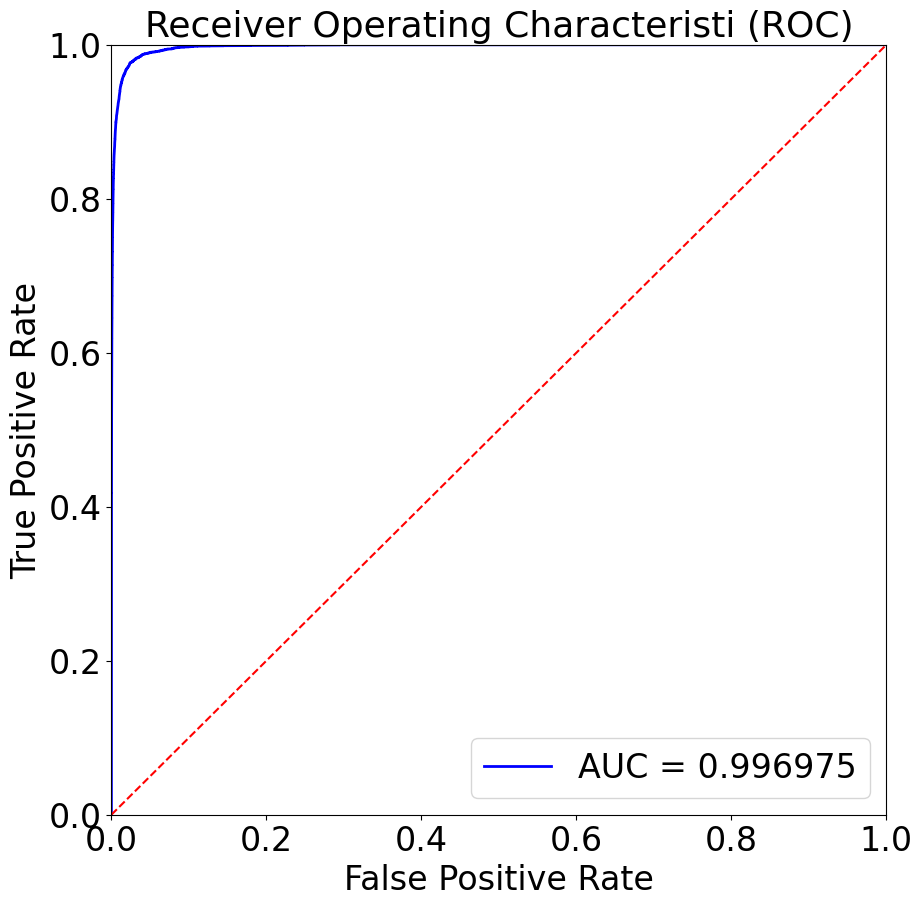

In [32]:
import sklearn.metrics as metrics
probs = model.predict_proba(X_eval)
preds = probs[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_eval, preds)
roc_auc = metrics.auc(fpr, tpr)

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10,10)
plt.title('Receiver Operating Characteristi (ROC)', fontsize=26)
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.6f' % roc_auc, linewidth=2)
plt.legend(loc = 'lower right', fontsize=24)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate', fontsize=24)
plt.xlabel('False Positive Rate', fontsize=24)
plt.xticks(fontsize=24) 
plt.yticks(fontsize=24) 
plt.show()

In [33]:
print(model.get_best_score())
print(model.get_all_params())


{'learn': {'Accuracy:use_weights=true': 0.9954192018636241, 'Logloss:use_weights=false': 0.025577703451085138, 'Logloss:use_weights=true': 0.019544118181305473, 'Logloss': 0.019544118181305473, 'Accuracy:use_weights=false': 0.9910302585170813, 'AUC': 0.9994343830997108}}
{'nan_mode': 'Min', 'eval_metric': 'Logloss', 'iterations': 1000, 'sampling_frequency': 'PerTree', 'leaf_estimation_method': 'Newton', 'od_pval': 0, 'random_score_type': 'NormalWithModelSizeDecrease', 'grow_policy': 'SymmetricTree', 'penalties_coefficient': 1, 'boosting_type': 'Plain', 'model_shrink_mode': 'Constant', 'feature_border_type': 'GreedyLogSum', 'bayesian_matrix_reg': 0.10000000149011612, 'eval_fraction': 0, 'force_unit_auto_pair_weights': False, 'l2_leaf_reg': 3, 'random_strength': 1, 'od_type': 'IncToDec', 'rsm': 1, 'boost_from_average': False, 'model_size_reg': 0.5, 'pool_metainfo_options': {'tags': {}}, 'subsample': 0.800000011920929, 'use_best_model': False, 'od_wait': 20, 'class_names': [False, True], 

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36],
 [Text(0, 0, 'L_P'),
  Text(0, 1, 'L_END_VY'),
  Text(0, 2, 'Lb_MAXDOCA'),
  Text(0, 3, 'L_CHI2'),
  Text(0, 4, 'L_BPVIP'),
  Text(0, 5, 'L_BPVDIRA'),
  Text(0, 6, 'xi_LP'),
  Text(0, 7, 'p_ETA'),
  Text(0, 8, 'pim_ETA'),
  Text(0, 9, 'Lb_P'),
  Text(0, 10, 'L_END_VZ'),
  Text(0, 11, 'L_END_VX'),
  Text(0, 12, 'Jpsi_PT'),
  Text(0, 13, 'L_BPVIPCHI2'),
  Text(0, 14, 'p_P'),
  Text(0, 15, 'mup_PID_MU'),
  Text(0, 16, 'Lb_CHI2'),
  Text(0, 17, 'Jpsi_ETA'),
  Text(0, 18, 'Jpsi_MAXDOCA'),
  Text(0, 19, 'xi_LbP'),
  Text(0, 20, 'Lb_ETA'),
  Text(0, 21, 'Lb_PT'),
  Text(0, 22, 'p_PID_P'),
  Text(0, 23, 'pim_PT'),
  Text(0, 24, 'p_PT'),
  Text(0, 25, 'Lb_BPVVDRHO'),
  Text(0, 26, 'L_END_VRHO'),
  Text(0, 27, 'Lb_MINIPCHI2'),
  Text(0, 28, 'pim_GHOSTPROB'),
  Text(0, 29, 'Jpsi_BPVDIRA'

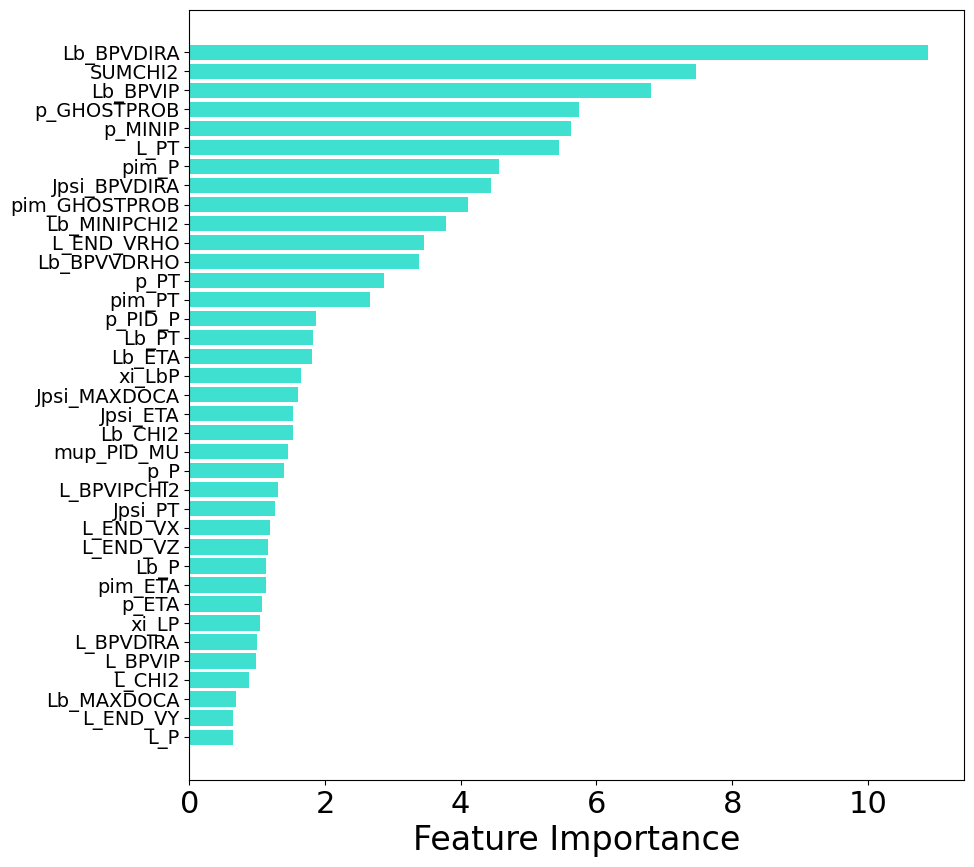

In [34]:
sorted_feature_importance = model.feature_importances_.argsort()
plt.rcParams["figure.figsize"] = (10,10)
plt.barh(X_eval.columns[sorted_feature_importance], 
        model.feature_importances_[sorted_feature_importance], 
        color='turquoise')
plt.xlabel("Feature Importance", fontsize=24)  # Ajusta el tamaño de fuente de las etiquetas en el eje y
# plt.title("Feature Importance", fontsize=24)
plt.xticks(fontsize=22)  # Ajusta el tamaño de fuente de las marcas en el eje x
plt.yticks(fontsize=14)  # Ajusta el tamaño de fuente de las etiquetas en el eje y

In [35]:
signal_MVA_prob_eval = model.predict_proba(X_eval_copy)
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
X_eval_copy['signal_MVA'] = signal_MVA_probs

signal_MVA_prob_tr = model.predict_proba(X_tr_copy)
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_tr]
X_tr_copy['signal_MVA'] = signal_MVA_probs

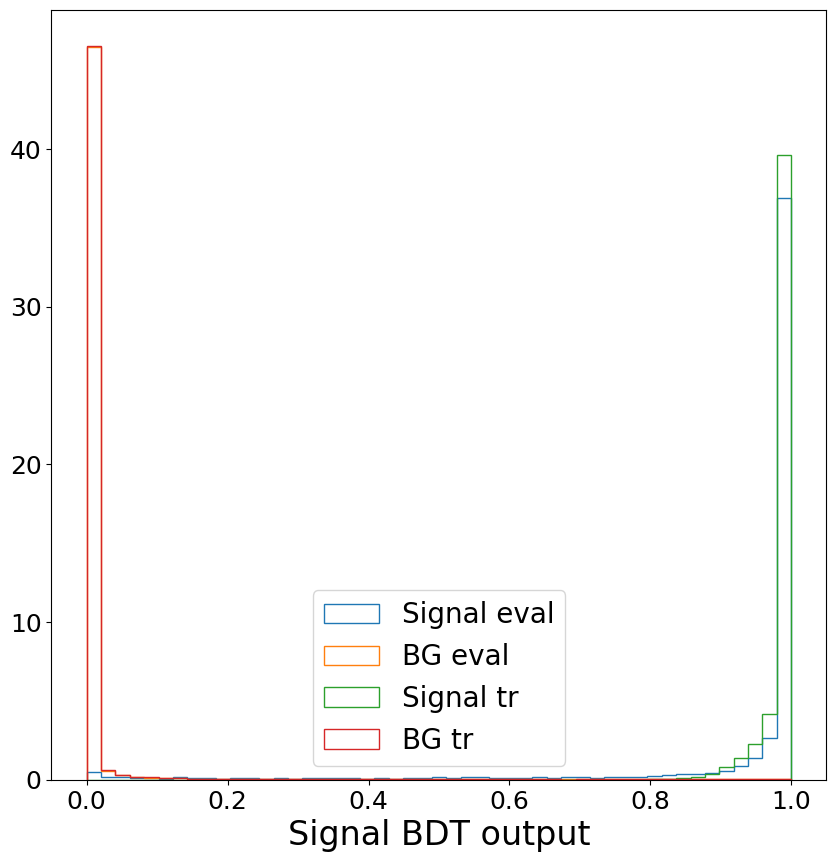

In [36]:
fig, ax = plt.subplots()

density = True

variable = 'signal_MVA'

bins = np.linspace(0,1,50)

n_sig,bins_sig, _ = ax.hist(X_eval_copy.query(f'SIGNAL')[variable], bins=bins, linewidth=1 ,label="Signal eval",histtype='step',density=density)
n_bg,bins_bg, _ = ax.hist(X_eval_copy.query(f'not SIGNAL')[variable], bins=bins, linewidth=1 ,label="BG eval",histtype='step',density=density)

ax.hist(X_tr_copy.query(f'SIGNAL')[variable], bins=bins, linewidth=1 ,label="Signal tr",histtype='step',density=density)
ax.hist(X_tr_copy.query(f'not SIGNAL')[variable], bins=bins, linewidth=1 ,label="BG tr",histtype='step',density=density)

ax.legend(fontsize=20)  # Ajusta el tamaño de fuente de la leyenda
ax.set_xlabel("Signal BDT output", fontsize=24)  # Ajusta el tamaño de fuente del eje x
plt.rcParams["figure.figsize"] = (15,10)
# Ajusta el tamaño de fuente de las marcas en los ejes x e y
# ax.tick_params(axis='both', which='major', labelsize=18)
plt.xticks(fontsize=18)  # Ajusta el tamaño de fuente de las marcas en el eje x
plt.yticks(fontsize=18)  # Ajusta el tamaño de fuente de las etiquetas en el eje y

plt.show()

In [37]:
model.save_model('new_BDT_5',
           format="cbm",
           export_parameters=None,
           pool=None)

In [38]:
for SIGNAL in [True, False]:
    print(f'SIGNAL == {SIGNAL}', len(new_training.query(f'(SIGNAL == {SIGNAL})')))

SIGNAL == True 28446
SIGNAL == False 1329453


In [39]:
data24_selected.columns

Index(['Lb_MASS', 'Jpsi_PT', 'Jpsi_ETA', 'Jpsi_MAXDOCA', 'Jpsi_BPVDIRA', 'L_P',
       'L_PT', 'L_CHI2', 'L_END_VZ', 'L_END_VX', 'L_END_VY', 'L_END_VRHO',
       'L_BPVDIRA', 'L_BPVIP', 'L_BPVIPCHI2', 'Lb_P', 'Lb_PT', 'Lb_CHI2',
       'Lb_MAXDOCA', 'Lb_BPVDIRA', 'Lb_BPVVDRHO', 'Lb_BPVIP', 'Lb_MINIPCHI2',
       'Lb_ETA', 'p_P', 'p_PT', 'p_ETA', 'p_PID_P', 'p_MINIP', 'p_GHOSTPROB',
       'pim_P', 'pim_ETA', 'pim_PT', 'pim_GHOSTPROB', 'mup_PID_MU',
       'Cos_xi_LP', 'Cos_xi_LbP', 'xi_LP', 'xi_LbP', 'SUMCHI2'],
      dtype='object')

In [40]:

data24= pd.read_pickle('data24_preselection_2.pkl')
data24['SUMCHI2'] = data24['L_CHI2'] + data24['Lb_CHI2'] + data24['Jpsi_CHI2']
data24_selected['EVENTNUMBER'] = data24['EVENTNUMBER']
data24_selected['p_PID_P'] = data24['p_PID_P']
data24_selected['SUMCHI2'] = data24['SUMCHI2']

prob = model.predict_proba(data24_selected)
print(prob)

signal_MVA_prob_eval = prob
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
data24_selected['prob'] = signal_MVA_probs

/tmp/javeser/ipykernel_15248/1328059281.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data24['SUMCHI2'] = data24['L_CHI2'] + data24['Lb_CHI2'] + data24['Jpsi_CHI2']


[[9.99014390e-01 9.85610114e-04]
 [9.99391297e-01 6.08703352e-04]
 [9.99966469e-01 3.35308625e-05]
 ...
 [1.00000000e+00 1.46269557e-12]
 [9.99999999e-01 7.22867996e-10]
 [9.87964046e-01 1.20359541e-02]]


In [41]:

data24_selected_chi2  = data24_selected[data24_selected.groupby(['EVENTNUMBER']).transform('min','SUMCHI2')['SUMCHI2']==data24_selected['SUMCHI2']].drop_duplicates('EVENTNUMBER')
data24_candidates  = data24_selected_chi2[data24_selected_chi2.groupby(['EVENTNUMBER']).transform('max','p_PID_P')['p_PID_P']==data24_selected_chi2['p_PID_P']].drop_duplicates()

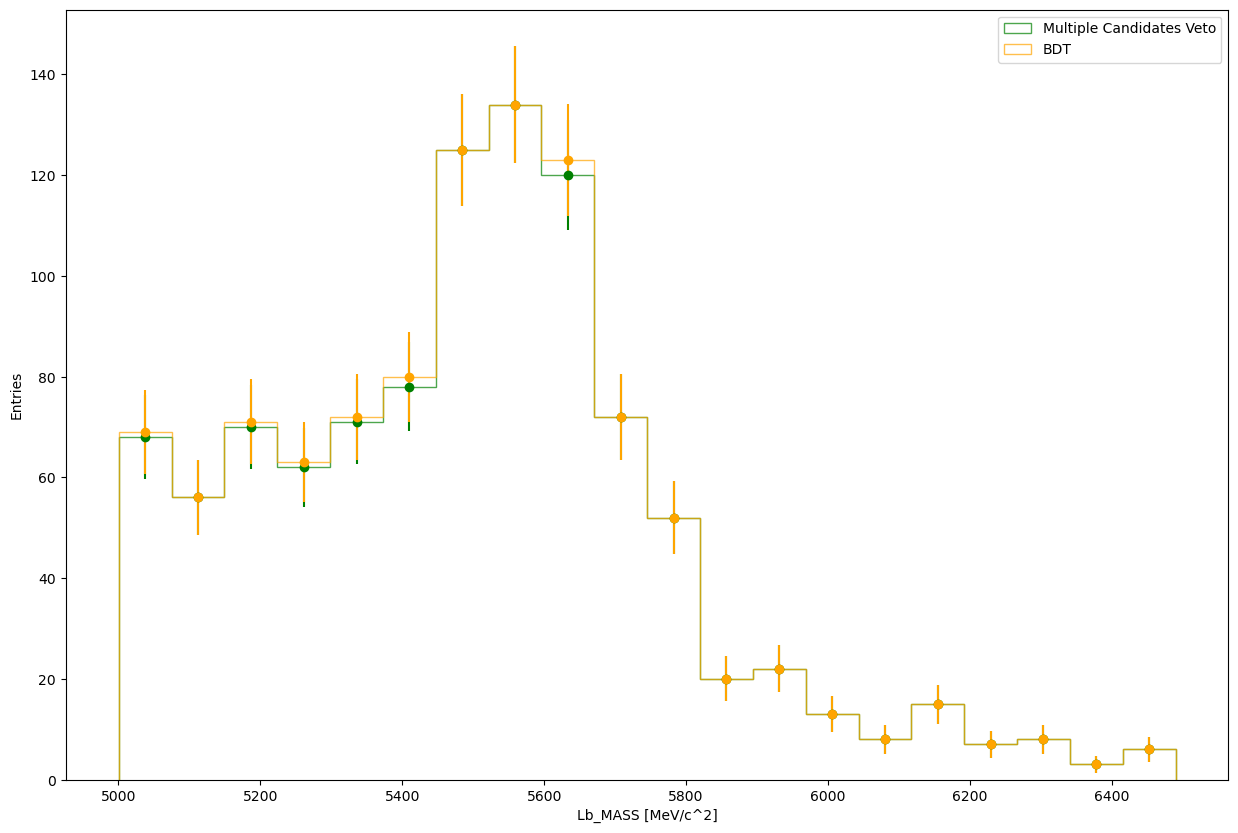

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create the figure and axes
fig, axes = plt.subplots()
binning = 20

# Plot histograms
hist1, bins1, _ = axes.hist(data24_candidates.query('(prob > 0.99)')['Lb_MASS'], bins=binning, label='Multiple Candidates Veto', color='green', alpha=0.7, histtype='step')
hist2, bins2, _ = axes.hist(data24_selected.query('(prob > 0.99)')['Lb_MASS'], bins=binning, label='BDT', color='orange', alpha=0.7, histtype='step')

# Calculate the bin centers for the error bars
bin_centers1 = 0.5 * (bins1[1:] + bins1[:-1])
bin_centers2 = 0.5 * (bins2[1:] + bins2[:-1])

# Plot error bars for the first histogram
axes.errorbar(
    bin_centers1,
    hist1,
    yerr=np.sqrt(hist1),
    fmt='o',
    color='green',
    # label='Binary Data',
    drawstyle='steps-mid'
)

# Plot error bars for the second histogram
axes.errorbar(
    bin_centers2,
    hist2,
    yerr=np.sqrt(hist2),
    fmt='o',
    color='orange',
    # label='MultiClass Data',
    drawstyle='steps-mid'
)

# Set labels and legend
plt.xlabel('Lb_MASS [MeV/c^2]')
plt.ylabel('Entries')
plt.legend()

# Display the plot
plt.show()


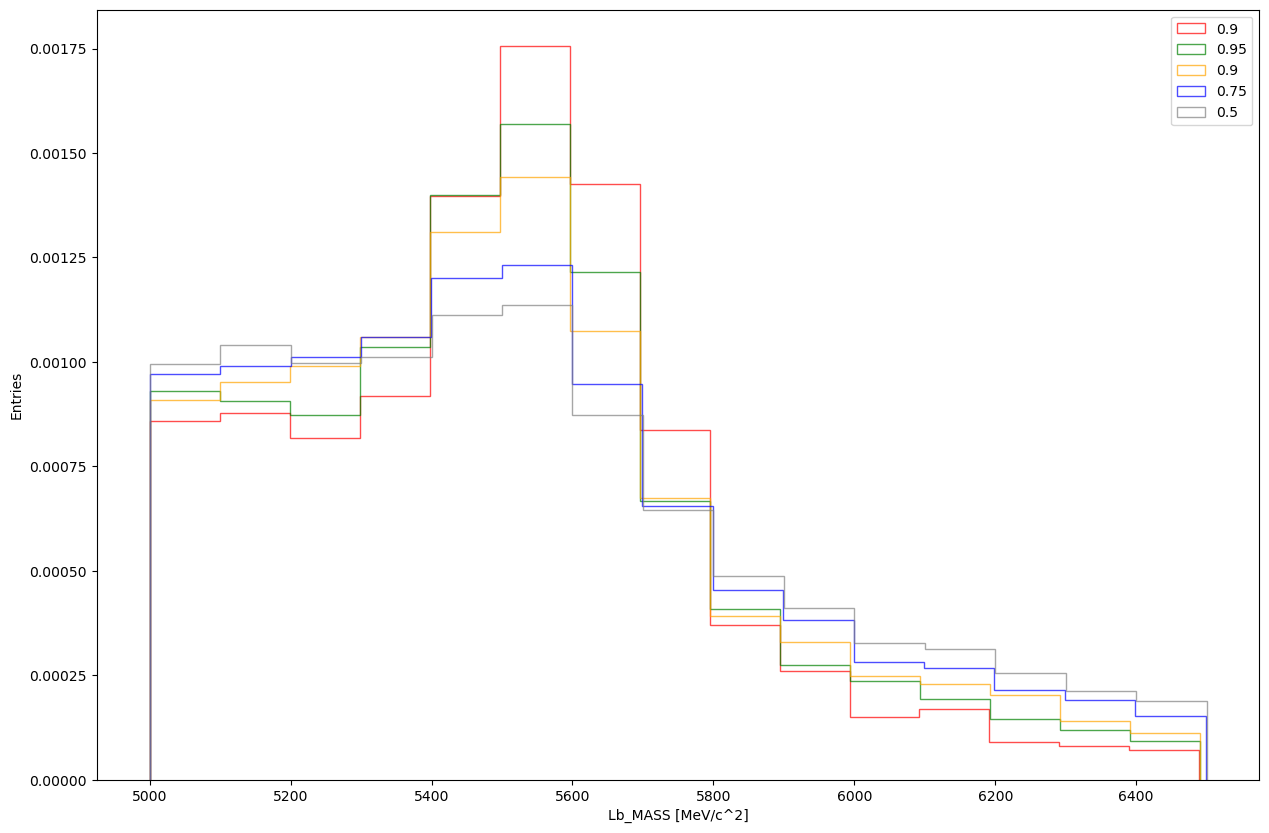

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create the figure and axes
fig, axes = plt.subplots()
binning = 15

density = True

# Plot histograms
hist1, bins1, _ = axes.hist(data24_candidates.query('(prob > 0.99)')['Lb_MASS'], bins=binning, label='0.9', color='red', alpha=0.7, histtype='step', density = density)
hist1, bins1, _ = axes.hist(data24_candidates.query('(prob > 0.95)')['Lb_MASS'], bins=binning, label='0.95', color='green', alpha=0.7, histtype='step', density = density)
hist2, bins2, _ = axes.hist(data24_candidates.query('(prob > 0.9)')['Lb_MASS'], bins=binning, label='0.9', color='orange', alpha=0.7, histtype='step', density = density)
hist1, bins1, _ = axes.hist(data24_candidates.query('(prob > 0.75)')['Lb_MASS'], bins=binning, label='0.75', color='blue', alpha=0.7, histtype='step', density = density)
hist2, bins2, _ = axes.hist(data24_candidates.query('(prob > 0.5)')['Lb_MASS'], bins=binning, label='0.5', color='grey', alpha=0.7, histtype='step', density = density)

# # Calculate the bin centers for the error bars
# bin_centers1 = 0.5 * (bins1[1:] + bins1[:-1])
# bin_centers2 = 0.5 * (bins2[1:] + bins2[:-1])

# # Plot error bars for the first histogram
# axes.errorbar(
#     bin_centers1,
#     hist1,
#     yerr=np.sqrt(hist1),
#     fmt='o',
#     color='green',
#     # label='Binary Data',
#     drawstyle='steps-mid'
# )

# # Plot error bars for the second histogram
# axes.errorbar(
#     bin_centers2,
#     hist2,
#     yerr=np.sqrt(hist2),
#     fmt='o',
#     color='orange',
#     # label='MultiClass Data',
#     drawstyle='steps-mid'
# )

# Set labels and legend
plt.xlabel('Lb_MASS [MeV/c^2]')
plt.ylabel('Entries')
plt.legend()

# Display the plot
plt.show()


In [44]:
print(model.get_best_score())
print(model.get_all_params())

{'learn': {'Accuracy:use_weights=true': 0.9954192018636241, 'Logloss:use_weights=false': 0.025577703451085138, 'Logloss:use_weights=true': 0.019544118181305473, 'Logloss': 0.019544118181305473, 'Accuracy:use_weights=false': 0.9910302585170813, 'AUC': 0.9994343830997108}}
{'nan_mode': 'Min', 'eval_metric': 'Logloss', 'iterations': 1000, 'sampling_frequency': 'PerTree', 'leaf_estimation_method': 'Newton', 'od_pval': 0, 'random_score_type': 'NormalWithModelSizeDecrease', 'grow_policy': 'SymmetricTree', 'penalties_coefficient': 1, 'boosting_type': 'Plain', 'model_shrink_mode': 'Constant', 'feature_border_type': 'GreedyLogSum', 'bayesian_matrix_reg': 0.10000000149011612, 'eval_fraction': 0, 'force_unit_auto_pair_weights': False, 'l2_leaf_reg': 3, 'random_strength': 1, 'od_type': 'IncToDec', 'rsm': 1, 'boost_from_average': False, 'model_size_reg': 0.5, 'pool_metainfo_options': {'tags': {}}, 'subsample': 0.800000011920929, 'use_best_model': False, 'od_wait': 20, 'class_names': [False, True], 